# Eniac A/B Test Analysis

## Homepage Button Experiment

This notebook analyses an A/B test for Eniac's homepage call-to-action button.

**Business question:** Which homepage button version performs best, and should Eniac replace the original white **"SHOP NOW"** button?

The experiment compared four button versions between **November 2 and November 16, 2021**.

| Version | Button Text | Colour | Type |
|---|---|---|---|
| A | SHOP NOW | White | Control |
| B | SHOP NOW | Red | Variant |
| C | SEE DEALS | White | Variant |
| D | SEE DEALS | Red | Variant |

## Data Sources and Limitations

The CSV files contain aggregated element-level click data, not individual visitor-level session data.  
Because of this, total visitor counts and some downstream metrics are taken from the case materials.

| Data | Source |
|---|---|
| Button clicks for Versions A, B, and D | CSV files, if available |
| Correct Version C click count | Case materials |
| Total visitors per version | Case materials |
| Drop-off rate | Case materials |
| Homepage-return rate | Case materials |

**Important data quality note:** in some provided files, Version C appears to be duplicated from Version A. For this reason, the correct Version C click count is set to **527**, based on the case materials.

In [1]:
# Import libraries

from pathlib import Path
from itertools import combinations
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

In [2]:

DATA_FILES = {
    "A": "eniac_a.csv",
    "B": "eniac_b.csv",
    "C": "eniac_c.csv",
    "D": "eniac_d.csv",
}

def find_data_file(filename):
    candidates = [
        Path("../data") / filename,
        Path("data") / filename,
        Path(filename),
        Path("/content") / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    return None

def load_version_data():
    data = {}
    for version, filename in DATA_FILES.items():
        path = find_data_file(filename)
        if path is None:
            data[version] = None
            print(f"Version {version}: file not found ({filename}). Case-material fallback values will be used where needed.")
        else:
            data[version] = pd.read_csv(path)
            print(f"Version {version}: loaded {path}")
    return data

version_data = load_version_data()

Version A: file not found (eniac_a.csv). Case-material fallback values will be used where needed.
Version B: file not found (eniac_b.csv). Case-material fallback values will be used where needed.
Version C: file not found (eniac_c.csv). Case-material fallback values will be used where needed.
Version D: file not found (eniac_d.csv). Case-material fallback values will be used where needed.


## 1. Data Quality Check

Before running the statistical analysis, the CSV files are checked for basic quality issues.

The main issue is whether the Version C file contains the correct **"SEE DEALS"** data or whether it is a duplicate of Version A.

In [3]:
# Combine available CSV files for inspection

available_frames = []

for version, frame in version_data.items():
    if frame is not None:
        temp = frame.copy()
        temp["version"] = version
        available_frames.append(temp)

if available_frames:
    df = pd.concat(available_frames, ignore_index=True)
    print(f"Combined dataset shape: {df.shape}")
    display(df.head())
else:
    df = pd.DataFrame()
    print("No CSV files loaded. The statistical analysis will still run using the case-material values.")

No CSV files loaded. The statistical analysis will still run using the case-material values.


In [4]:
# Check whether Version A and Version C are identical

if version_data.get("A") is not None and version_data.get("C") is not None:
    a_frame = version_data["A"].reset_index(drop=True)
    c_frame = version_data["C"].reset_index(drop=True)

    same_shape = a_frame.shape == c_frame.shape
    identical = same_shape and a_frame.equals(c_frame)

    print(f"Version A and C same shape: {same_shape}")
    print(f"Version A and C identical: {identical}")

    if identical:
        print("\nData quality finding: Version C appears to be a duplicate of Version A.")
        print("The correct Version C click count will be taken from the case materials.")
else:
    print("Version A and/or Version C file is unavailable, so the duplicate check cannot be completed.")

Version A and/or Version C file is unavailable, so the duplicate check cannot be completed.


In [5]:
# Helper function to extract button clicks from a CSV file

def get_button_clicks(frame, button_name, fallback_value):
    """Return the button click count from a CSV file, or fallback if unavailable."""
    if frame is None:
        return fallback_value

    required_columns = {"Name", "No. clicks"}
    if not required_columns.issubset(frame.columns):
        return fallback_value

    matches = frame.loc[frame["Name"] == button_name, "No. clicks"]

    if matches.empty:
        return fallback_value

    return int(matches.iloc[0])


# Button clicks
# A, B, and D are extracted from CSV files when available.
# C is manually set because the provided C file may be corrupted/duplicated.

clicks = {
    "A": get_button_clicks(version_data.get("A"), "SHOP NOW", 512),
    "B": get_button_clicks(version_data.get("B"), "SHOP NOW", 281),
    "C": 527,
    "D": get_button_clicks(version_data.get("D"), "SEE DEALS", 193),
}

clicks_df = pd.DataFrame({
    "Version": list(clicks.keys()),
    "Clicks": list(clicks.values())
})

clicks_df

,Version,Clicks
0,A,512
1,B,281
2,C,527
3,D,193


## 2. Contingency Table and Click-Through Rate

The chi-square test compares the number of clicks and no-clicks across the four button versions.

Total visitor counts are taken from the case materials.

In [6]:
# Total visitors per version from the case materials

visitors = {
    "A": 25326,
    "B": 24747,
    "C": 24876,
    "D": 25233,
}

no_clicks = {
    version: visitors[version] - clicks[version]
    for version in visitors
}

contingency_df = pd.DataFrame(
    {
        f"Version_{version}": [clicks[version], no_clicks[version]]
        for version in ["A", "B", "C", "D"]
    },
    index=["Click", "No-click"]
)

contingency_df

,Version_A,Version_B,Version_C,Version_D
Click,512,281,527,193
No-click,24814,24466,24349,25040


In [7]:
# Calculate click-through rate per version

button_labels = {
    "A": "White SHOP NOW",
    "B": "Red SHOP NOW",
    "C": "White SEE DEALS",
    "D": "Red SEE DEALS",
}

ctr_df = pd.DataFrame({
    "version": list(visitors.keys()),
    "button": [button_labels[v] for v in visitors],
    "clicks": [clicks[v] for v in visitors],
    "visitors": [visitors[v] for v in visitors],
})

ctr_df["ctr"] = ctr_df["clicks"] / ctr_df["visitors"]
ctr_df["ctr_percent"] = ctr_df["ctr"] * 100

ctr_df.sort_values("ctr_percent", ascending=False)

,version,button,clicks,visitors,ctr,ctr_percent
2,C,White SEE DEALS,527,24876,0.021185,2.118508
0,A,White SHOP NOW,512,25326,0.020216,2.021638
1,B,Red SHOP NOW,281,24747,0.011355,1.135491
3,D,Red SEE DEALS,193,25233,0.007649,0.764871


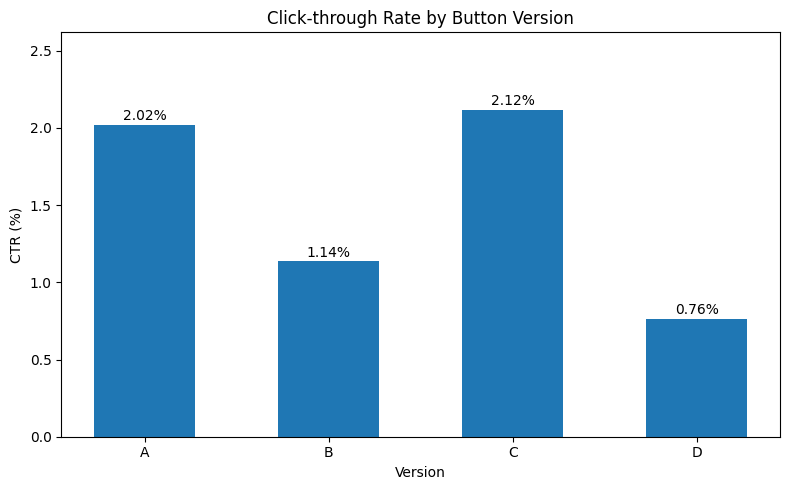

In [8]:
# Visualise click-through rate by version

plt.figure(figsize=(8, 5))

bars = plt.bar(
    ctr_df["version"],
    ctr_df["ctr_percent"],
    width=0.55
)

for bar, value in zip(bars, ctr_df["ctr_percent"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        f"{value:.2f}%",
        ha="center"
    )

plt.title("Click-through Rate by Button Version")
plt.xlabel("Version")
plt.ylabel("CTR (%)")
plt.ylim(0, max(ctr_df["ctr_percent"]) + 0.5)
plt.tight_layout()
plt.show()

## 3. Overall Chi-Square Test

The chi-square test checks whether the observed click-through differences across the four versions are statistically significant.

**Null hypothesis:** all button versions have the same click-through rate.  
**Alternative hypothesis:** at least one button version has a different click-through rate.

Significance level: **α = 0.05**

In [9]:
# Overall chi-square test

alpha = 0.05

chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_df)

print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.10f}")

if p_value < alpha:
    print("\nDecision: Reject the null hypothesis.")
    print("At least one button version performs significantly differently.")
else:
    print("\nDecision: Fail to reject the null hypothesis.")
    print("There is not enough evidence to conclude that the versions perform differently.")

Chi-square statistic: 224.0188
Degrees of freedom: 3
p-value: 0.0000000000

Decision: Reject the null hypothesis.
At least one button version performs significantly differently.


In [10]:
# Expected values under the null hypothesis

expected_df = pd.DataFrame(
    expected,
    index=contingency_df.index,
    columns=contingency_df.columns
)

expected_df

,Version_A,Version_B,Version_C,Version_D
Click,382.486255,373.7419,375.690124,381.081721
No-click,24943.513745,24373.2581,24500.309876,24851.918279


## 4. Post-Hoc Pairwise Tests

The overall chi-square test shows that a difference exists, but it does not show which specific versions differ.

To compare each pair of versions, pairwise chi-square tests are used.

There are six pairwise comparisons, so a Bonferroni correction is applied:

**Adjusted α = 0.05 / 6 = 0.0083**

In [11]:
# Pairwise chi-square tests with Bonferroni correction

versions = ["A", "B", "C", "D"]
comparison_pairs = list(combinations(versions, 2))
alpha_adjusted = alpha / len(comparison_pairs)

pairwise_results = []

for v1, v2 in comparison_pairs:
    pair_table = pd.DataFrame(
        {
            v1: [clicks[v1], no_clicks[v1]],
            v2: [clicks[v2], no_clicks[v2]],
        },
        index=["Click", "No-click"]
    )

    chi2_pair, p_pair, dof_pair, expected_pair = stats.chi2_contingency(pair_table)

    pairwise_results.append({
        "comparison": f"{v1} vs {v2}",
        "chi2": chi2_pair,
        "p_value": p_pair,
        "significant_after_bonferroni": p_pair < alpha_adjusted
    })

pairwise_df = pd.DataFrame(pairwise_results)
pairwise_df

,comparison,chi2,p_value,significant_after_bonferroni
0,A vs B,62.493623,2.673088e-15,True
1,A vs C,0.534210,4.648421e-01,False
2,A vs D,144.283184,3.080898e-33,True
3,B vs C,74.229172,6.955480e-18,True
4,B vs D,17.876340,2.357337e-05,True
5,C vs D,161.117041,6.450501e-37,True


## 5. Additional Business Metrics

Click-through rate alone does not fully determine the best version.

A button can receive slightly more clicks but still perform worse if users abandon the process after clicking.

The case materials also provide two downstream metrics:

- **Drop-off rate:** percentage of users who clicked but did not complete a purchase. Lower is better.
- **Homepage-return rate:** percentage of users who returned to the homepage after clicking. Lower is better.

Version B does not have complete data for these downstream metrics.

In [12]:
# Additional metrics from the case materials

additional_metrics = pd.DataFrame({
    "version": ["A", "C", "D"],
    "button": ["White SHOP NOW", "White SEE DEALS", "Red SEE DEALS"],
    "drop_off_rate": [62.0, 71.0, 69.5],
    "homepage_return_rate": [5.3, 4.7, 2.6],
})

additional_metrics

,version,button,drop_off_rate,homepage_return_rate
0,A,White SHOP NOW,62.0,5.3
1,C,White SEE DEALS,71.0,4.7
2,D,Red SEE DEALS,69.5,2.6


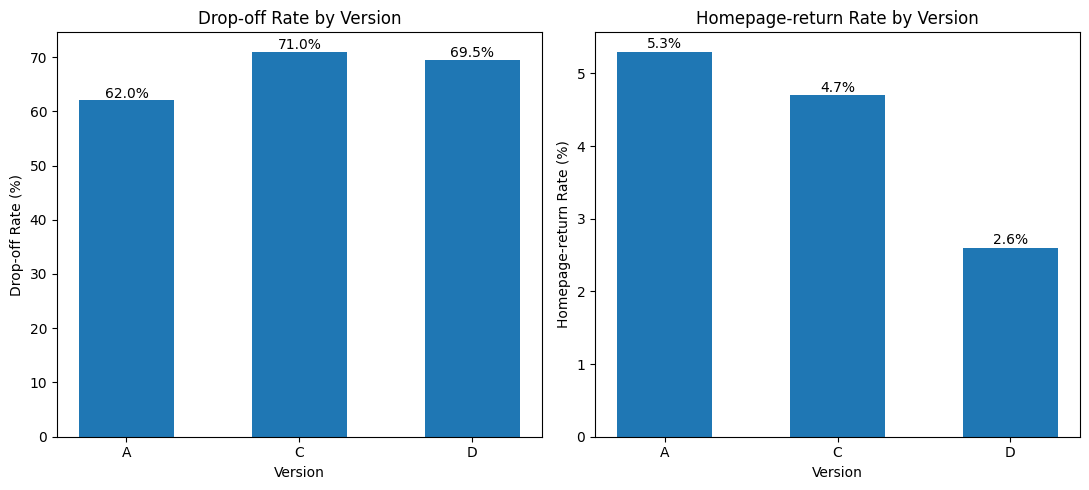

In [13]:
# Visualise additional business metrics

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].bar(additional_metrics["version"], additional_metrics["drop_off_rate"], width=0.55)
axes[0].set_title("Drop-off Rate by Version")
axes[0].set_xlabel("Version")
axes[0].set_ylabel("Drop-off Rate (%)")
for i, value in enumerate(additional_metrics["drop_off_rate"]):
    axes[0].text(i, value + 0.5, f"{value:.1f}%", ha="center")

axes[1].bar(additional_metrics["version"], additional_metrics["homepage_return_rate"], width=0.55)
axes[1].set_title("Homepage-return Rate by Version")
axes[1].set_xlabel("Version")
axes[1].set_ylabel("Homepage-return Rate (%)")
for i, value in enumerate(additional_metrics["homepage_return_rate"]):
    axes[1].text(i, value + 0.05, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()

## 6. Weighted Score

Version C has a slightly higher CTR than Version A, but A and C are not significantly different in the pairwise test.

To support the business decision, a weighted score is used to combine the available metrics.

Weights:

- **CTR:** 50%
- **Drop-off rate:** 25%
- **Homepage-return rate:** 25%

CTR is better when higher. Drop-off rate and homepage-return rate are better when lower.

Version B is excluded from the weighted score because downstream metric data is unavailable.

In [14]:
# Weighted score calculation

score_df = ctr_df[ctr_df["version"].isin(["A", "C", "D"])].copy()
score_df = score_df.merge(
    additional_metrics[["version", "drop_off_rate", "homepage_return_rate"]],
    on="version",
    how="left"
)

def normalize(series, higher_is_better=True):
    """Normalize a numeric series to a 0-1 scale."""
    min_value = series.min()
    max_value = series.max()

    if max_value == min_value:
        return pd.Series([0.5] * len(series), index=series.index)

    normalized = (series - min_value) / (max_value - min_value)

    if higher_is_better:
        return normalized

    return 1 - normalized

score_df["ctr_score"] = normalize(score_df["ctr_percent"], higher_is_better=True)
score_df["drop_off_score"] = normalize(score_df["drop_off_rate"], higher_is_better=False)
score_df["homepage_return_score"] = normalize(score_df["homepage_return_rate"], higher_is_better=False)

score_df["weighted_score"] = (
    score_df["ctr_score"] * 0.50
    + score_df["drop_off_score"] * 0.25
    + score_df["homepage_return_score"] * 0.25
)

score_df.sort_values("weighted_score", ascending=False)

,version,button,clicks,visitors,ctr,ctr_percent,drop_off_rate,homepage_return_rate,ctr_score,drop_off_score,homepage_return_score,weighted_score
0,A,White SHOP NOW,512,25326,0.020216,2.021638,62.0,5.3,0.928437,1.000000,0.000000,0.714219
1,C,White SEE DEALS,527,24876,0.021185,2.118508,71.0,4.7,1.000000,0.000000,0.222222,0.555556
2,D,Red SEE DEALS,193,25233,0.007649,0.764871,69.5,2.6,0.000000,0.166667,1.000000,0.291667


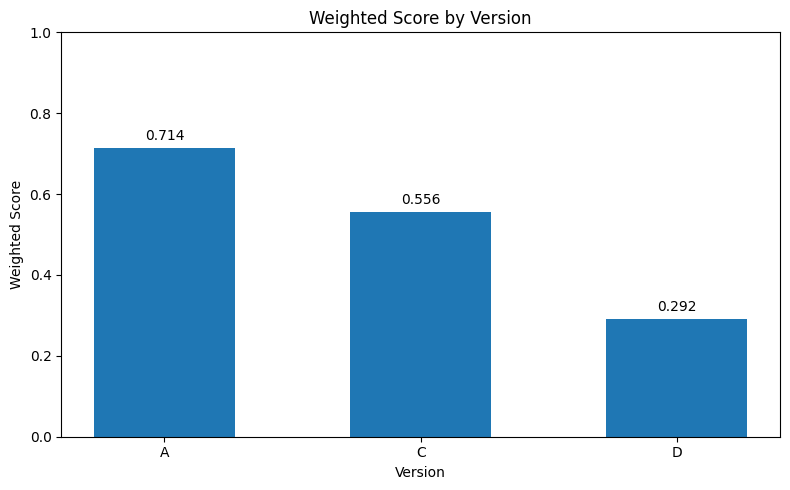

In [15]:
# Visualise weighted score ranking

ranking = score_df.sort_values("weighted_score", ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(ranking["version"], ranking["weighted_score"], width=0.55)

for bar, value in zip(bars, ranking["weighted_score"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.title("Weighted Score by Version")
plt.xlabel("Version")
plt.ylabel("Weighted Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 7. Final Recommendation

The overall chi-square test shows that the button versions do not perform equally.

However, the pairwise comparison between **Version A** and **Version C** is not statistically significant. This means CTR alone does not provide strong enough evidence to replace the original button with Version C.

Version B and Version D perform clearly worse and should not be used.

Although Version C has a slightly higher CTR, Version A performs better on the most important downstream metric: drop-off rate.

A lower drop-off rate means users who click Version A are more likely to continue towards purchase instead of abandoning the process.

## Final Decision

Eniac should keep the original white **"SHOP NOW"** button.

Future experiments should focus on clearer, product-specific call-to-action text, such as **"Shop iPhones"** or **"Shop Accessories"**, while avoiding major colour changes that may reduce user engagement.

In [16]:
# Final summary table

final_summary = pd.DataFrame({
    "Version": ["A - White SHOP NOW", "B - Red SHOP NOW", "C - White SEE DEALS", "D - Red SEE DEALS"],
    "CTR (%)": [
        ctr_df.loc[ctr_df["version"] == "A", "ctr_percent"].iloc[0],
        ctr_df.loc[ctr_df["version"] == "B", "ctr_percent"].iloc[0],
        ctr_df.loc[ctr_df["version"] == "C", "ctr_percent"].iloc[0],
        ctr_df.loc[ctr_df["version"] == "D", "ctr_percent"].iloc[0],
    ],
    "Drop-off Rate (%)": [62.0, np.nan, 71.0, 69.5],
    "Homepage-return Rate (%)": [5.3, np.nan, 4.7, 2.6],
})

final_summary

,Version,CTR (%),Drop-off Rate (%),Homepage-return Rate (%)
0,A - White SHOP NOW,2.021638,62.0,5.3
1,B - Red SHOP NOW,1.135491,NaN,NaN
2,C - White SEE DEALS,2.118508,71.0,4.7
3,D - Red SEE DEALS,0.764871,69.5,2.6
